In [14]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from arch import arch_model
from sklearn.metrics import (
accuracy_score, precision_score,recall_score, 
f1_score, roc_auc_score,confusion_matrix, 
ConfusionMatrixDisplay,RocCurveDisplay)

### Load master dataframe

Loading the cleaned dataframe that was saved in preprocessing_eda.ipynb

In [2]:
df = pd.read_csv("data/processed/master.csv", index_col="date", parse_dates= True)
print(df.shape)
print(df.head())

(5012, 9)
            sp500_return  vix_diff  t2y_diff  t10y_diff  fedfunds_diff  \
date                                                                     
2005-02-02      0.003173     -0.37      0.03       0.00          -0.11   
2005-02-03     -0.002770      0.13      0.02       0.03           0.20   
2005-02-04      0.010983     -0.58     -0.05      -0.09           0.02   
2005-02-07     -0.001090      0.52      0.02      -0.02          -0.01   
2005-02-08      0.000483     -0.13      0.02      -0.02          -0.02   

            credit_diff  realized_vol  yield_spread_diff  regime  
date                                                              
2005-02-02        -0.01      0.101165              -0.03       0  
2005-02-03        -0.03      0.092876               0.01       0  
2005-02-04        -0.01      0.099116              -0.04       0  
2005-02-07        -0.04      0.098798              -0.04       0  
2005-02-08        -0.02      0.098536              -0.04       0  


### Setting fixed values

VIX is expressed as a percentage, but GARCH requires decimal so below I am setting the threshold as 0.2

The reasoning behind setting TRAIN_SIZE as 756 is that it ensures GARCH gets atleast one meaningful narket cycle before making its forecast. 
$ 756 \text{ trading days} = \text{approximately 3 years of market data(252 days x 3)} $

In [4]:
VOL_THRESHOLD = 0.20
TRAIN_SIZE = 756

### Walk forward validation for GARCH

In [5]:
returns = df["sp500_return"] * 100
actual_labels = df["regime"].values

garch_vol_forecasts = []
garch_dates = []

print(f"Training window: expanding from {TRAIN_SIZE} days")
print(f"Test period: {df.index[TRAIN_SIZE].date()} to {df.index[-1].date()}")

Training window: expanding from 756 days
Test period: 2008-02-05 to 2024-12-31


In [6]:
print(f"\nRunning walk-forward GARCH validation")
for t in range(TRAIN_SIZE, len(returns)):
    train_returns = returns.iloc[:t]

    #fitting GARCH(1,1) with normal errors
    model  = arch_model(train_returns, vol="Garch", p=1, q=1,
                        dist="normal", rescale=False)
    result = model.fit(disp="off")

    #One-step-ahead variance forecast
    forecast     = result.forecast(horizon=1, reindex=False)
    var_forecast = forecast.variance.values[-1, 0]  

    ann_vol = np.sqrt(var_forecast / 10000) * np.sqrt(252)

    garch_vol_forecasts.append(ann_vol)
    garch_dates.append(df.index[t])

    if t % 250 == 0:
        print(f"  Progress: {t}/{len(returns)} ({t/len(returns):.0%})")

print("Walk-forward complete.")


Running walk-forward GARCH validation
  Progress: 1000/5012 (20%)
  Progress: 1250/5012 (25%)
  Progress: 1500/5012 (30%)
  Progress: 1750/5012 (35%)
  Progress: 2000/5012 (40%)
  Progress: 2250/5012 (45%)
  Progress: 2500/5012 (50%)
  Progress: 2750/5012 (55%)
  Progress: 3000/5012 (60%)
  Progress: 3250/5012 (65%)
  Progress: 3500/5012 (70%)
  Progress: 3750/5012 (75%)
  Progress: 4000/5012 (80%)
  Progress: 4250/5012 (85%)
  Progress: 4500/5012 (90%)
  Progress: 4750/5012 (95%)
  Progress: 5000/5012 (100%)
Walk-forward complete.


The above loop implements walk-forward validation for GARCH. For each day t starting from day 756:
1. Fit GARCH(1,1) on all returns upto day t
2. Predict next day's variance
3. Turn variance into annualized volatility (divide by 10000 because returns were in percentage units, multiply by √252 to annualize)
4. Save forecast and date

### Convert forecasts to regime predictions

In [8]:
garch_vol_forecasts = np.array(garch_vol_forecasts)
garch_preds = (garch_vol_forecasts > VOL_THRESHOLD).astype(int)
actual_test = actual_labels[TRAIN_SIZE:]

### Evaluation metrics

In [9]:
metrics = {
    "Model": "GARCH(1,1)",
    "Accuracy": round(accuracy_score(actual_test, garch_preds), 4),
    "Precision": round(precision_score(actual_test, garch_preds, zero_division=0), 4),
    "Recall": round(recall_score(actual_test, garch_preds, zero_division=0), 4),
    "F1 Score": round(f1_score(actual_test, garch_preds, zero_division=0), 4),
    "ROC-AUC": round(roc_auc_score(actual_test, garch_vol_forecasts), 4),
}

metrics_df = pd.DataFrame([metrics])
print(f"\nGARCH Classification Metrics:")
print(metrics_df.to_string(index=False))


GARCH Classification Metrics:
     Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
GARCH(1,1)    0.8217     0.9264  0.5571    0.6958   0.9077


GARCH(1,1) achieves strong overall accuracy of 82% and precision of 93%, meaning when it predicts turbulent regime it is usually right. However, its recall of 56% reveals a significant weakness, so it misses nearly half of all actual turbulent days, which is a very costly error in practice.

### Understanding from plots

### Plot 1: Predicted vs Actual regimes over time

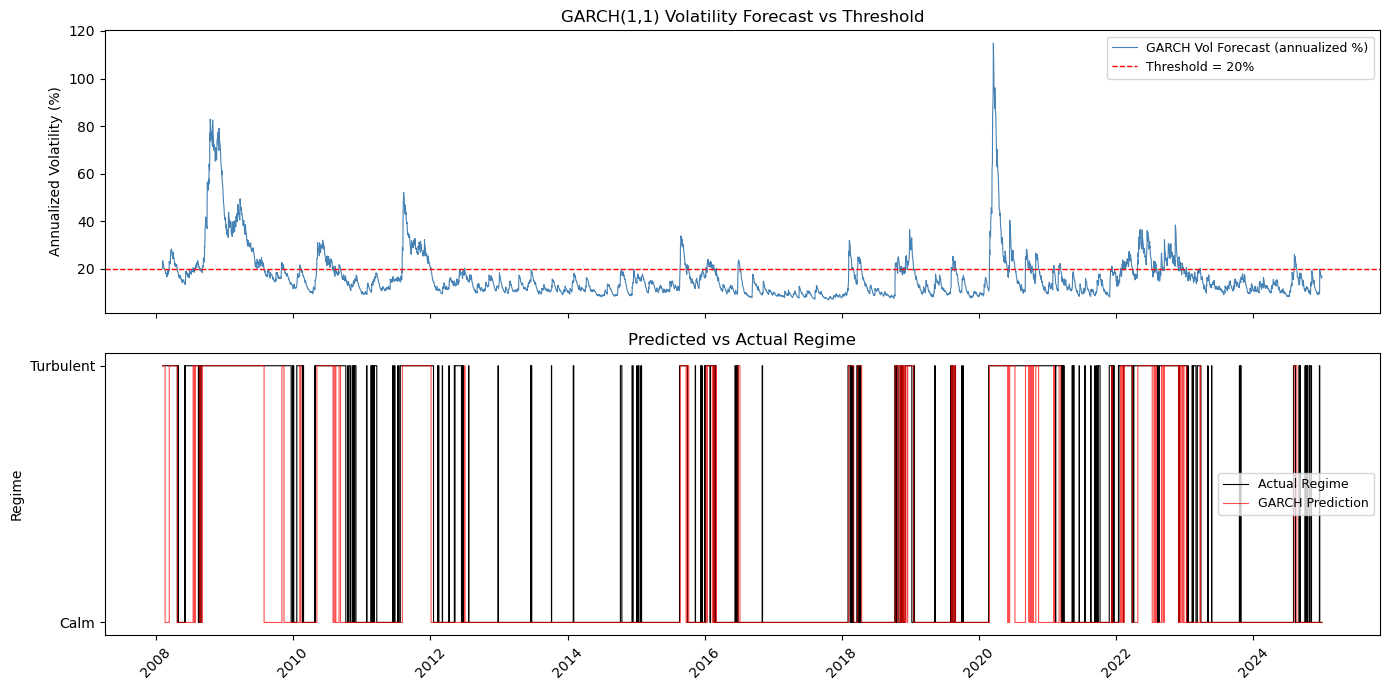

In [10]:

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

#Top panel: GARCH annualized vol forecast with threshold
axes[0].plot(garch_dates, garch_vol_forecasts * 100,
             color="steelblue", linewidth=0.8, label="GARCH Vol Forecast (annualized %)")
axes[0].axhline(VOL_THRESHOLD * 100, color="red", linestyle="--",
                linewidth=1, label=f"Threshold = {VOL_THRESHOLD*100:.0f}%")
axes[0].set_ylabel("Annualized Volatility (%)")
axes[0].set_title("GARCH(1,1) Volatility Forecast vs Threshold")
axes[0].legend(fontsize=9)

#Bottom panel: predicted vs actual regime
axes[1].step(garch_dates, actual_test, color="black",
             linewidth=0.8, label="Actual Regime", where="post")
axes[1].step(garch_dates, garch_preds, color="red",
             linewidth=0.8, alpha=0.7, label="GARCH Prediction", where="post")
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(["Calm", "Turbulent"])
axes[1].set_ylabel("Regime")
axes[1].set_title("Predicted vs Actual Regime")
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("plots/garch_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

The top panel shows GARCH's annualized volatility forecast over time, it captures the two major crisis spikes ie. 2008 global financial crisis and 2020 COVID and correctly stays below it during calm periods like 2013–2017.

The bottom panel reveals GARCH's main weakness. The red predictions tend to lag the black actual regime lines, meaning GARCH recognizes turbulence only after it has already materialized in returns, rather than predicting it before it hits. This lagging behavior directly explains the low recall of 56%, by the time GARCH's variance estimate crosses the threshold, the turbulent period is often already underway or nearly over.

### Plot 2: Confusion matrix

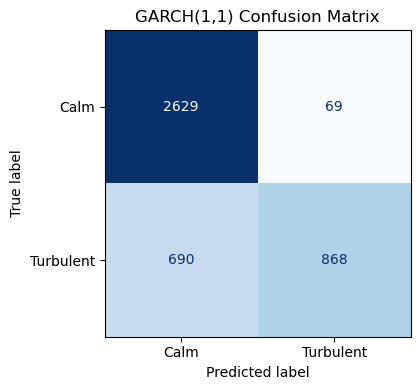

In [11]:
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(actual_test, garch_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Calm", "Turbulent"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("GARCH(1,1) Confusion Matrix")
plt.tight_layout()
plt.savefig("plots/garch_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

GARCH correctly identifies 2629 calm days and 868 turbulent days. But misclassifies 690 turbulent days as calm and 69 calm days as turbulent. Missing 690 turbulent days is quite a big problem, whereas 69 false alarms is comparatively minor.

### Plot 3: ROC Curve

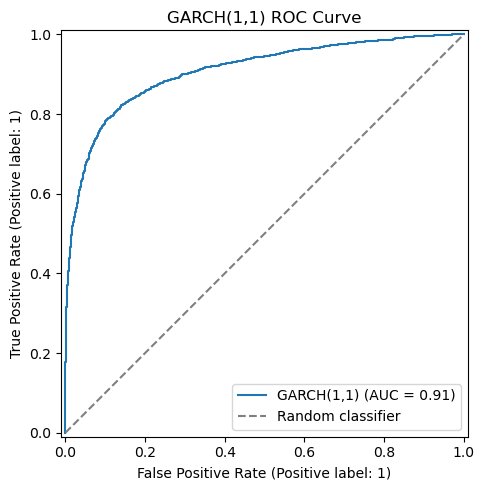

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(actual_test, garch_vol_forecasts,
                                  name="GARCH(1,1)", ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
ax.set_title("GARCH(1,1) ROC Curve")
ax.legend()
plt.tight_layout()
plt.savefig("plots/garch_roc.png", dpi=150, bbox_inches="tight")
plt.show()

The AUC of 0.91 is quite strong, meaning its volatility signal is good but its recall suffers.
The issue is that GARCH's annualized volatility forecast is a smoothed, lagged estimate because GARCH averages past squared returns, its forecast rarely jumps sharply. It goes up gradually towards the threshold 20%. So on many genuinely turbulent days, GARCH's forecast might be at 18% or 19%, correctly predicting stress but not quite crossing 20% and so gets classified as calm.

### Saving GARCH forecasts for later comparison with LSTM

In [15]:
garch_results = pd.DataFrame({
    "date": garch_dates,
    "garch_vol": garch_vol_forecasts,
    "garch_pred": garch_preds,
    "actual_regime": actual_test,
}).set_index("date")

os.makedirs("data/processed", exist_ok=True)
garch_results.to_csv("data/processed/garch_results.csv")
print(f"\nGARCH results saved to data/processed/garch_results.csv")


GARCH results saved to data/processed/garch_results.csv
